# Twitter Sentiment Analysis — Logistic Regression
**Course:** Large Scale Data Analysis (33:136:487) — Spring 2026  
**Creator:** Krish Patel  
**Model:** Logistic Regression  
**Dataset:** Sentiment140 — 1.6 million tweets  
**Dataset Link:** https://www.kaggle.com/datasets/kazanova/sentiment140

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings('ignore')

In [2]:
col_names = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df = pd.read_csv(
    '/training.1600000.processed.noemoticon 2.csv',
    encoding='latin-1',
    header=None,
    names=col_names
)

df = df[['sentiment', 'text']]
df['sentiment'] = df['sentiment'].replace(4, 1)

print(f'Dataset shape: {df.shape}')
print(df['sentiment'].value_counts())

Dataset shape: (1600000, 2)
sentiment
0    800000
1    800000
Name: count, dtype: int64


In [3]:
sample_size = 50000

neg = df[df['sentiment'] == 0].sample(sample_size, random_state=42)
pos = df[df['sentiment'] == 1].sample(sample_size, random_state=42)

df_sample = pd.concat([neg, pos]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Sample size: {len(df_sample)} tweets')
print(df_sample['sentiment'].value_counts())

Sample size: 100000 tweets
sentiment
1    50000
0    50000
Name: count, dtype: int64


In [4]:
STOP_WORDS = set(stopwords.words('english'))

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in STOP_WORDS]
    return ' '.join(words)

df_sample['clean_text'] = df_sample['text'].apply(clean_tweet)

print('BEFORE:', df_sample['text'].iloc[0])
print('AFTER: ', df_sample['clean_text'].iloc[0])

BEFORE: @stargazer60 that's awesome 
AFTER:  thats awesome


In [5]:
X = df_sample['clean_text']
y = df_sample['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Training matrix shape: {X_train_tfidf.shape}')
print(f'Testing matrix shape:  {X_test_tfidf.shape}')

Training matrix shape: (80000, 50000)
Testing matrix shape:  (20000, 50000)


In [6]:
lr_model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)
print('Model trained.')

Model trained.


In [7]:
y_pred = lr_model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Test Accuracy: 0.7713 (77.13%)

              precision    recall  f1-score   support

    Negative       0.78      0.76      0.77     10000
    Positive       0.76      0.78      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



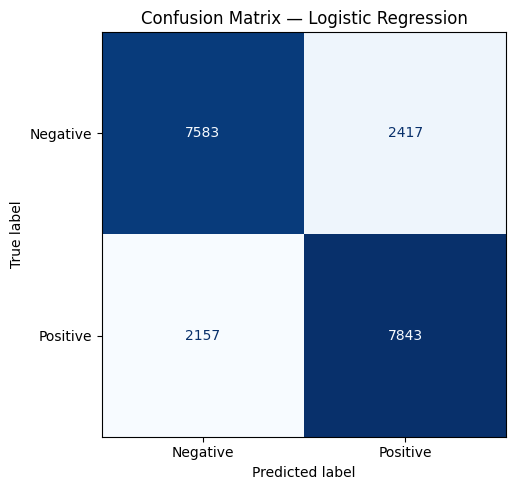

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f'Best C: {grid_search.best_params_["C"]}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

results_df = pd.DataFrame(grid_search.cv_results_)[['param_C', 'mean_test_score', 'std_test_score']]
results_df.columns = ['C', 'Mean Accuracy', 'Std Dev']
print(results_df.to_string(index=False))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C: 1
Best CV accuracy: 0.7685
     C  Mean Accuracy  Std Dev
  0.01       0.732712 0.003434
  0.10       0.751850 0.001476
  1.00       0.768525 0.002035
 10.00       0.756550 0.002006
100.00       0.728463 0.001592


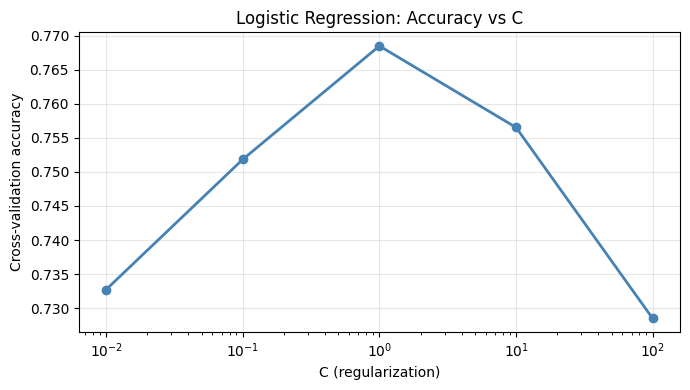

In [10]:
c_values = param_grid['C']
mean_scores = grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(7, 4))
plt.semilogx(c_values, mean_scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel('C (regularization)')
plt.ylabel('Cross-validation accuracy')
plt.title('Logistic Regression: Accuracy vs C')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cv_regularization_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_tfidf)

best_acc = accuracy_score(y_test, y_pred_best)
print(f'Final Accuracy (C={grid_search.best_params_["C"]}): {best_acc:.4f} ({best_acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred_best, target_names=['Negative', 'Positive']))

Final Accuracy (C=1): 0.7713 (77.13%)

              precision    recall  f1-score   support

    Negative       0.78      0.76      0.77     10000
    Positive       0.76      0.78      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



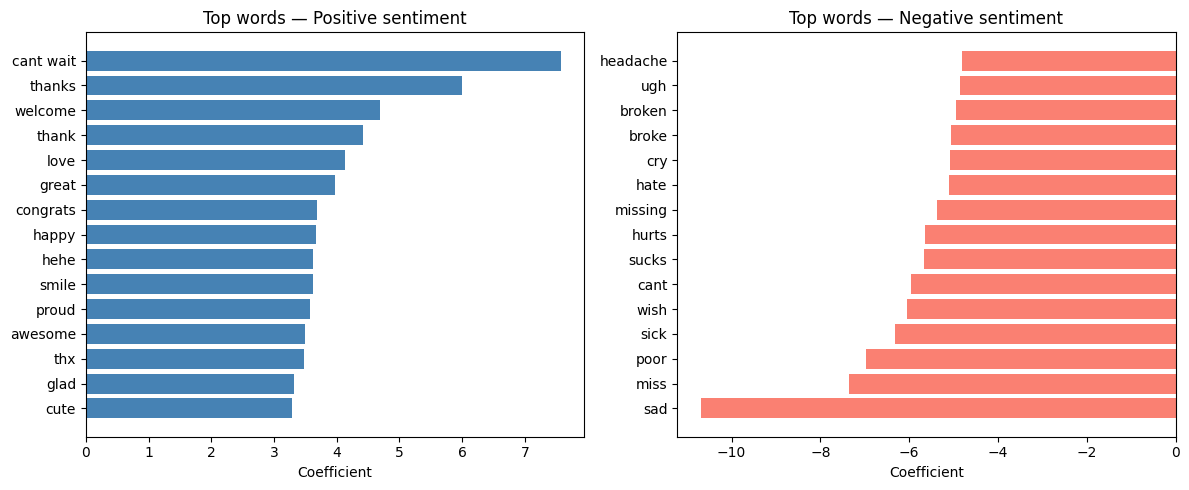

In [12]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = best_model.coef_[0]

top_n = 15
top_pos_idx = np.argsort(coefficients)[-top_n:][::-1]
top_neg_idx = np.argsort(coefficients)[:top_n]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.barh(feature_names[top_pos_idx][::-1], coefficients[top_pos_idx][::-1], color='steelblue')
ax1.set_title('Top words — Positive sentiment')
ax1.set_xlabel('Coefficient')

ax2.barh(feature_names[top_neg_idx], coefficients[top_neg_idx], color='salmon')
ax2.set_title('Top words — Negative sentiment')
ax2.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('top_words_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
def predict_sentiment(tweet_text):
    cleaned = clean_tweet(tweet_text)
    vectorized = tfidf.transform([cleaned])
    prediction = best_model.predict(vectorized)[0]
    probability = best_model.predict_proba(vectorized)[0]
    label = 'POSITIVE' if prediction == 1 else 'NEGATIVE'
    confidence = max(probability) * 100
    print(f'Tweet: "{tweet_text}"')
    print(f'Sentiment: {label}  (confidence: {confidence:.1f}%)')
    print()

predict_sentiment("I love this sunny day, feeling great!")
predict_sentiment("This is the worst day ever, so frustrated.")
predict_sentiment("Just had an okay lunch, nothing special.")

Tweet: "I love this sunny day, feeling great!"
Sentiment: POSITIVE  (confidence: 78.2%)

Tweet: "This is the worst day ever, so frustrated."
Sentiment: NEGATIVE  (confidence: 89.1%)

Tweet: "Just had an okay lunch, nothing special."
Sentiment: POSITIVE  (confidence: 65.3%)



## Results Summary

| Metric | Value |
|--------|-------|
| Model | Logistic Regression |
| Dataset | Sentiment140 (100,000 tweets) |
| Features | TF-IDF (unigrams + bigrams, top 50,000) |
| Train/Test Split | 80% / 20% |
| Hyperparameter Tuning | 5-fold cross-validation over C = [0.01, 0.1, 1, 10, 100] |

This confusion matrix shows that the Logistic Regression model achieved the highest accuracy among the group at 77.13%, correctly identifying positive and negative tweets at similar rates (78% and 76% precision respectively). TF-IDF with bigrams was used to convert tweet text into numerical features, which allowed the model to capture two-word phrases like "not good" that single-word features would miss. Hyperparameter tuning via 5-fold cross-validation confirmed that C=1 was the optimal regularization strength. We considered using Word2Vec embeddings as an alternative but chose TF-IDF for its simplicity and strong performance on this dataset size.